In [7]:
# Install required libraries (run once)
!pip install pandas sqlalchemy ipython-sql duckdb

# Import libraries
import pandas as pd
import sqlite3
import duckdb
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the CSV file
df = pd.read_csv(r"C:\Users\DELL\Downloads\mining_supply_sales.csv")

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (100, 4)

First 5 rows:
    sale_date   product_name  quantity  amount
0  2025-07-10         Cement        10     500
1  2025-07-10  Excavator Oil         5    1500
2  2025-07-10         Helmet        20     300
3  2025-07-10         Gloves        15     225
4  2025-07-11         Cement        12     600

Data types:
sale_date         str
product_name      str
quantity        int64
amount          int64
dtype: object

Missing values:
sale_date       0
product_name    0
quantity        0
amount          0
dtype: int64


In [8]:
#Create SQLite database
conn = sqlite3.connect('mining_supply_db')

#load DataFrame to SQL Table
df.to_sql('Sales', conn, if_exists='replace', index=False)

#Verify
print(pd.read_sql_query("SELECT COUNT (*) as total_rows FROM sales", conn))

   total_rows
0         100


In [9]:
#1.Total revenue and quantity sold
query1 = """ 
SELECT
     COUNT(*) as total_transactions,
     SUM(quantity) as total_quantity_sold,
     SUM(amount) as total_revenue,
     ROUND(AVG(amount), 2) as avg_transaction_value
     FROM sales
     """
print(pd.read_sql_query(query1, conn))

#2. Top 10 products by revenue
query2 = """
SELECT
     product_name,
     SUM(quantity) as total_quantity,
     SUM(amount) as total_revenue,
     ROUND(AVG(amount), 2) as avg_sale_value
     FROM sales
     GROUP BY product_name
     ORDER BY total_revenue DESC
     LIMIT 10
"""
top_products = pd.read_sql_query(query2, conn)
print(top_products)

#3. Daily Sales Analysis
query3 = """
SELECT
    sale_date,
    COUNT(*) as num_transactions,
    SUM(quantity) as quantity_sold,
    SUM(amount) as daily_revenue
    FROM sales
    GROUP BY sale_date
    ORDER BY sale_date
"""
daily_sales = pd.read_sql_query(query3, conn)
print(daily_sales.head(10))

   total_transactions  total_quantity_sold  total_revenue  \
0                 100                 2986         691722   

   avg_transaction_value  
0                6917.22  
         product_name  total_quantity  total_revenue  avg_sale_value
0         Jackhammers             263          75173        10739.00
1              Chains             175          46801        11700.25
2                Fuel             188          39265         5609.29
3              Helmet             263          34467         3829.67
4          Generators             129          33281         8320.25
5               Ropes             103          32321        10773.67
6           Hard Hats             113          31744         6348.80
7      Conveyor Belts             164          31506         7876.50
8  Protective Glasses             152          31271         5211.83
9          Lubricants             158          30794         5132.33
    sale_date  num_transactions  quantity_sold  daily_revenue
0 

In [10]:
#Advanced Analytics
# 4. Product performance with ranking
query4 = """
WITH product_stats AS (
    SELECT 
        product_name,
        COUNT(*) as frequency,
        SUM(quantity) as total_quantity,
        SUM(amount) as total_revenue,
        ROUND(AVG(amount), 2) as avg_revenue
    FROM sales
    GROUP BY product_name
)
SELECT 
    *,
    RANK() OVER (ORDER BY total_revenue DESC) as revenue_rank,
    RANK() OVER (ORDER BY frequency DESC) as frequency_rank
FROM product_stats
WHERE total_revenue > 5000
ORDER BY total_revenue DESC
"""
product_ranking = pd.read_sql_query(query4, conn)
print(product_ranking)

# 5. Moving average (7-day rolling)
query5 = """
SELECT 
    sale_date,
    daily_revenue,
    AVG(daily_revenue) OVER (
        ORDER BY sale_date 
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ) as revenue_7day_ma
FROM (
    SELECT 
        sale_date,
        SUM(amount) as daily_revenue
    FROM sales
    GROUP BY sale_date
)
ORDER BY sale_date
"""
moving_avg = pd.read_sql_query(query5, conn)
print(moving_avg.tail(10))

# 6. Price per unit analysis
query6 = """
SELECT 
    product_name,
    ROUND(AVG(amount * 1.0 / quantity), 2) as avg_price_per_unit,
    MIN(amount * 1.0 / quantity) as min_price,
    MAX(amount * 1.0 / quantity) as max_price,
    COUNT(*) as num_sales
FROM sales
WHERE quantity > 0
GROUP BY product_name
HAVING num_sales > 1
ORDER BY avg_price_per_unit DESC
LIMIT 10
"""
price_analysis = pd.read_sql_query(query6, conn)
print(price_analysis)

          product_name  frequency  total_quantity  total_revenue  avg_revenue  \
0          Jackhammers          7             263          75173     10739.00   
1               Chains          4             175          46801     11700.25   
2                 Fuel          7             188          39265      5609.29   
3               Helmet          9             263          34467      3829.67   
4           Generators          4             129          33281      8320.25   
5                Ropes          3             103          32321     10773.67   
6            Hard Hats          5             113          31744      6348.80   
7       Conveyor Belts          4             164          31506      7876.50   
8   Protective Glasses          6             152          31271      5211.83   
9           Lubricants          6             158          30794      5132.33   
10        Safety Boots          3              92          30438     10146.00   
11        Crane Cables      

In [11]:
#Time Series Analysis
#7. Weekly and monthly aggregations
query7 = """ 
SELECT 
     STRFTIME('%Y-%m', sale_date) as month,
     STRFTIME('%W', sale_date) as week,
     COUNT(*) as transactions,
     SUM(amount) as revenue,
     SUM(quantity) as quantity,
     COUNT(DISTINCT product_name) as unique_products
     FROM sales
     GROUP BY STRFTIME('%Y-%m', sale_date),
     STRFTIME('%W', sale_date)
     ORDER BY month, week
     """
time_series = pd.read_sql_query(query7, conn)
print(time_series.head(10))

#8. Best and worst performing days
query8b = """
SELECT
     sale_date,
     SUM(amount) as revenue,
     COUNT(DISTINCT product_name) as products_solid,
     SUM(quantity) as total_items
     FROM sales
     GROUP BY sale_date
     ORDER BY revenue DESC
     LIMIT 5
"""
worst_days = pd.read_sql_query(query8b, conn)
print("\nBottom 5 revenue days:\n", worst_days)

     month week  transactions  revenue  quantity  unique_products
0  2025-07   27            26   143813       597               16
1  2025-07   28            25   177956       757               16
2  2025-07   29            37   280328      1257               20
3  2025-07   30            12    89625       375               10

Bottom 5 revenue days:
     sale_date  revenue  products_solid  total_items
0  2025-07-25    81690               5          267
1  2025-07-14    66902               8          273
2  2025-07-21    60818               7          233
3  2025-07-23    59575               8          293
4  2025-07-29    56258               6          184


In [12]:
#Customer/Product Segmentation
#9. ABC Analysis (Pareto - 80/20 rule)
query9 = """
WITH product_revenue AS (
     SELECT
          product_name,
          SUM(amount) as revenue,
          SUM(amount) * 100.0 / SUM(SUM(amount)) OVER () as revenue_percentage
          FROM sales
          GROUP BY product_name
),
cumulative AS (
    SELECT
        product_name,
        revenue,
        revenue_percentage,
        SUM(revenue_percentage) OVER (ORDER BY revenue DESC) as cumulative_percentage
        FROM product_revenue
)
SELECT
     product_name,
     ROUND(revenue, 2) as revenue,
     ROUND(revenue_percentage, 2) as pct_of_total,
     ROUND(cumulative_percentage, 2) as cumulative_pct,
     CASE
        WHEN cumulative_percentage <= 80 THEN 'A - Top Products'
        WHEN cumulative_percentage <= 95 THEN 'B - Medium Products'
        ELSE 'C - Low Products'
    END as abc_category
    FROM cumulative
    ORDER BY revenue DESC
"""
abc_analysis = pd.read_sql_query(query9, conn)
print(abc_analysis.head(15))

          product_name  revenue  pct_of_total  cumulative_pct  \
0          Jackhammers  75173.0         10.87           10.87   
1               Chains  46801.0          6.77           17.63   
2                 Fuel  39265.0          5.68           23.31   
3               Helmet  34467.0          4.98           28.29   
4           Generators  33281.0          4.81           33.10   
5                Ropes  32321.0          4.67           37.78   
6            Hard Hats  31744.0          4.59           42.37   
7       Conveyor Belts  31506.0          4.55           46.92   
8   Protective Glasses  31271.0          4.52           51.44   
9           Lubricants  30794.0          4.45           55.89   
10        Safety Boots  30438.0          4.40           60.29   
11        Crane Cables  29917.0          4.33           64.62   
12         Spare Tires  27704.0          4.01           68.62   
13    Ventilation Fans  22107.0          3.20           71.82   
14      First Aid Kits  2

In [13]:
#Using DuckDB for Faster Analytics
# DuckDB can query DataFrames directly without SQLite
import duckdb

# Register DataFrame
duckdb.register('sales_df', df)

# Run complex query
result = duckdb.sql("""
    SELECT 
        product_name,
        SUM(amount) as total_revenue,
        SUM(quantity) as total_quantity,
        STDDEV(amount) as revenue_volatility,
        COUNT(*) as frequency
    FROM sales_df
    GROUP BY product_name
    HAVING COUNT(*) > 1
    ORDER BY total_revenue DESC
""").df()

print(result.head(10))

# Percentile analysis
percentiles = duckdb.sql("""
    SELECT 
        product_name,
        APPROX_QUANTILE(amount, 0.25) as q1,
        APPROX_QUANTILE(amount, 0.5) as median,
        APPROX_QUANTILE(amount, 0.75) as q3,
        APPROX_QUANTILE(amount, 0.9) as p90
    FROM sales_df
    GROUP BY product_name
    ORDER BY median DESC
    LIMIT 10
""").df()

print("\nPrice distribution by product:\n", percentiles)

         product_name  total_revenue  total_quantity  revenue_volatility  \
0         Jackhammers        75173.0           263.0         6408.713912   
1              Chains        46801.0           175.0         5087.945255   
2                Fuel        39265.0           188.0         6511.283328   
3              Helmet        34467.0           263.0         3210.178617   
4          Generators        33281.0           129.0         6063.020225   
5               Ropes        32321.0           103.0         3581.432302   
6           Hard Hats        31744.0           113.0         4666.407098   
7      Conveyor Belts        31506.0           164.0         3760.985110   
8  Protective Glasses        31271.0           152.0         4021.378192   
9          Lubricants        30794.0           158.0         3958.917310   

   frequency  
0          7  
1          4  
2          7  
3          9  
4          4  
5          3  
6          5  
7          4  
8          6  
9          6 

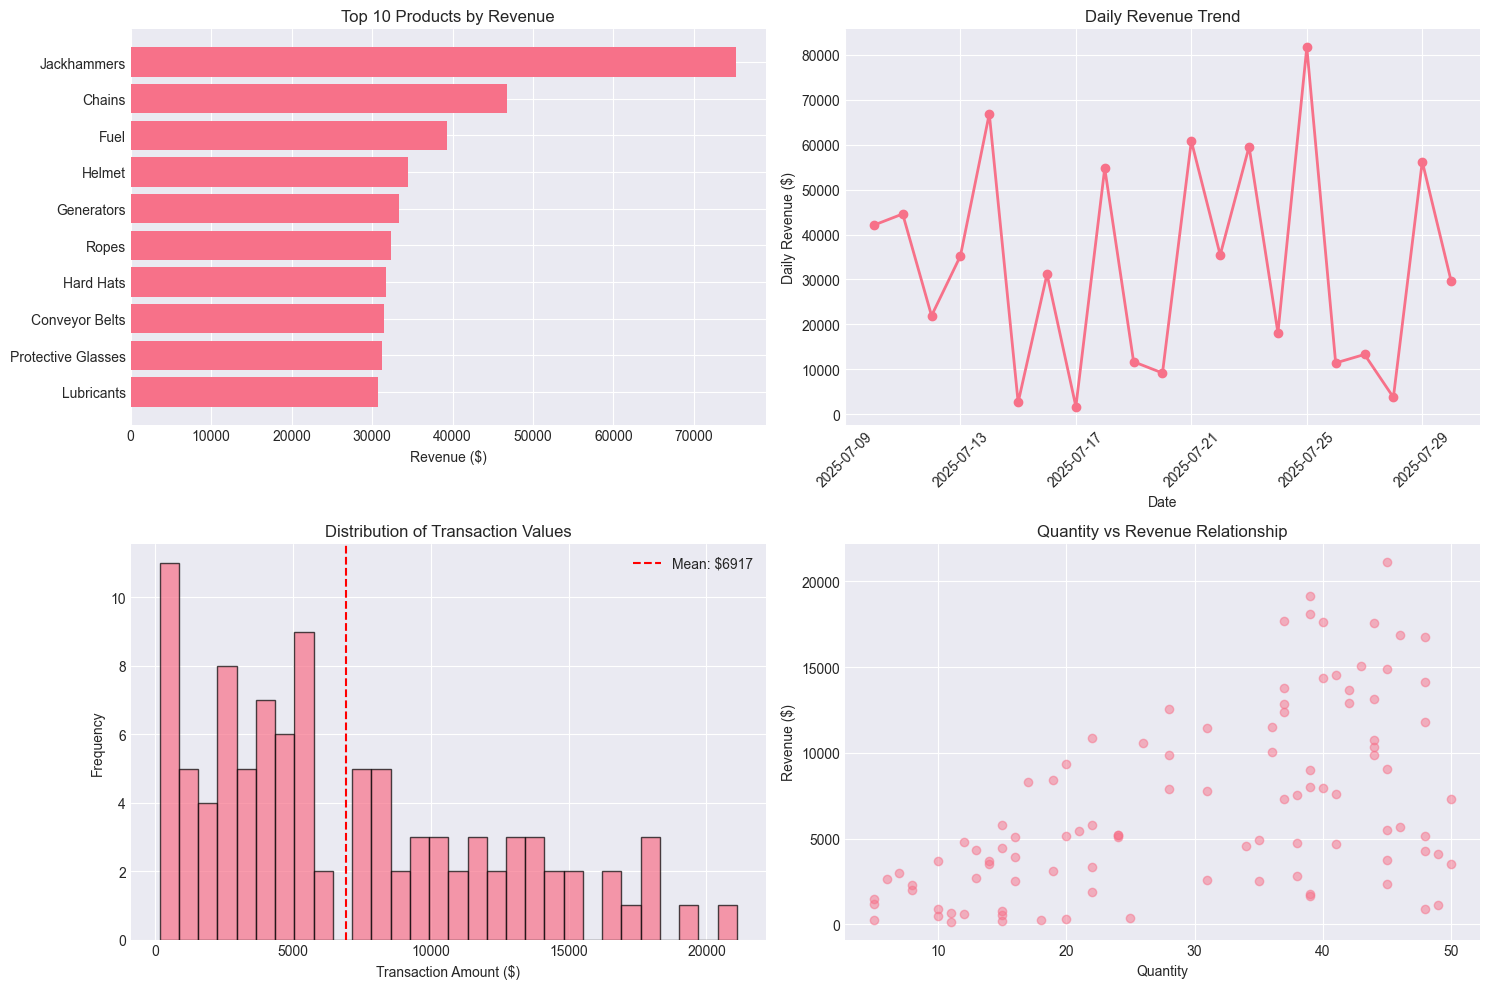

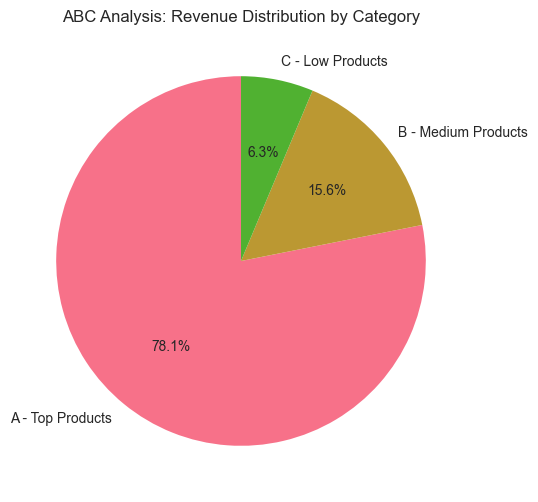

In [14]:
#Data Visualization
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Top products revenue bar chart
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top 10 products by revenue
top_10 = top_products.head(10)
axes[0,0].barh(top_10['product_name'], top_10['total_revenue'])
axes[0,0].set_xlabel('Revenue ($)')
axes[0,0].set_title('Top 10 Products by Revenue')
axes[0,0].invert_yaxis()

# Daily revenue trend
daily_sales['sale_date'] = pd.to_datetime(daily_sales['sale_date'])
axes[0,1].plot(daily_sales['sale_date'], daily_sales['daily_revenue'], marker='o', linewidth=2)
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Daily Revenue ($)')
axes[0,1].set_title('Daily Revenue Trend')
axes[0,1].tick_params(axis='x', rotation=45)

# Revenue distribution
axes[1,0].hist(df['amount'], bins=30, edgecolor='black', alpha=0.7)
axes[1,0].set_xlabel('Transaction Amount ($)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Transaction Values')
axes[1,0].axvline(df['amount'].mean(), color='red', linestyle='--', label=f'Mean: ${df["amount"].mean():.0f}')
axes[1,0].legend()

# Quantity vs Revenue scatter
axes[1,1].scatter(df['quantity'], df['amount'], alpha=0.5)
axes[1,1].set_xlabel('Quantity')
axes[1,1].set_ylabel('Revenue ($)')
axes[1,1].set_title('Quantity vs Revenue Relationship')

plt.tight_layout()
plt.show()

# 2. ABC Analysis Pie Chart
abc_summary = abc_analysis.groupby('abc_category')['revenue'].sum()
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(abc_summary, labels=abc_summary.index, autopct='%1.1f%%', startangle=90)
ax.set_title('ABC Analysis: Revenue Distribution by Category')
plt.show()

In [16]:
#Advanced Insights with window functions
#10. Product growth analysis
query10 = """
WITH daily_product_sales AS (
     SELECT
          product_name,
          sale_date,
          SUM(amount) as daily_revenue
          FROM sales
          GROUP BY product_name, sale_date
),
ranked_sales AS (
     SELECT
          product_name,
          sale_date,
          daily_revenue,
          LAG(daily_revenue, 1) OVER (PARTITION BY product_name ORDER BY sale_date) as prev_day_revenue,
          LEAD(daily_revenue, 1) OVER (PARTITION BY product_name ORDER BY sale_date) as next_day_revenue
          FROM daily_product_sales
)
SELECT
      product_name,
      sale_date,
      daily_revenue,
      CASE
         WHEN prev_day_revenue IS NULL THEN 'First Sale'
         WHEN daily_revenue > prev_day_revenue THEN 'Increase'
         WHEN daily_revenue < prev_day_revenue THEN 'Decrease'
         ELSE 'Same'
         END as day_over_day_trend
         FROM ranked_sales
         WHERE product_name IN (
         SELECT product_name
         FROM sales
         GROUP BY product_name
         ORDER BY SUM(amount) DESC
         LIMIT 5
)
ORDER BY product_name, sale_date
"""
trend_analysis = pd.read_sql_query(query10, conn)
print(trend_analysis.head(30))

   product_name   sale_date  daily_revenue day_over_day_trend
0        Chains  2025-07-14          14360         First Sale
1        Chains  2025-07-21          17556           Increase
2        Chains  2025-07-24           7585           Decrease
3        Chains  2025-07-27           7300           Decrease
4          Fuel  2025-07-10          10890         First Sale
5          Fuel  2025-07-14           2850           Decrease
6          Fuel  2025-07-23           2385           Decrease
7          Fuel  2025-07-25          18651           Increase
8          Fuel  2025-07-28           3724           Decrease
9          Fuel  2025-07-29            765           Decrease
10   Generators  2025-07-13          15093         First Sale
11   Generators  2025-07-14          11439           Decrease
12   Generators  2025-07-17           1677           Decrease
13   Generators  2025-07-18           5072           Increase
14       Helmet  2025-07-10            300         First Sale
15      

In [23]:
#Save all Analysis results
with pd.ExcelWriter('mining_supply_analysis_report.xlsx') as writer:
    top_products.to_excel(writer, sheet_name='Top Products', index=False)
    daily_sales.to_excel(writer, sheet_name='Daily Sales', index=False)
    product_ranking.to_excel(writer, sheet_name='Product Ranking', index=False)
    price_analysis.to_excel(writer, sheet_name='Price Analysis', index=False)
    abc_analysis.to_excel(writer, sheet_name='ABC Analysis', index=False)
    time_series.to_excel(writer, sheet_name='Time Series', index=False)

    #Summary stats
    summary = pd.DataFrame({
    'Metric': ['Total Revenue', 'Total Quantity', 'Total Transaction', 'Avg Transaction Value', 'Unique Products', 'Data Range'],
    'Value': [f"${df['amount'].sum():,.2f}",
              f"{df['quantity'].sum():,}",
              f"{len(df):,}",
              f"{df['amount'].mean():,.2f}",
              df['product_name'].nunique(),
              f"{df['sale_date'].min()} to {df['sale_date'].max()}"
             ]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

    print("Report saved as 'mining_supply_analysis_report.xlsx'")

    #Close connection
    conn.close()

Report saved as 'mining_supply_analysis_report.xlsx'
